In [1]:
import pandas as pd
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, utils
import matplotlib.pyplot as plt 
import numpy as np
import skgstat as skg
from tqdm import tqdm
from scipy.spatial.distance import pdist
import seaborn as sns
import json

sns.set_style('dark')

## Chen et al. dataset

**[Chen dataset](https://zenodo.org/records/7306199) (download the *.nc* file).**

This dataset is not a direct output from isotope-enabled GCMs. Instead, it has been generated through data fusion and bias correction techniques based on GCM outputs. In other words, post-processing methods were applied to the model outputs to bring the simulations closer to observational data. This dataset is 1870–2017 at a monthly scale.

First, we import useful libraries and read the netCTF4 file with xarray to get a Dataset object. 

In [2]:
fn = '../data/modern/PrecipOxygenIso_mainlandCHINA_1870to2017_v2.nc'

file = utils.load_xarray_datarray(fn)
d18Op = file.d18Op

# make the time dimension a datetime index, starting from 1870-01-01, with monthly frequence so that time 1 becomes 1870-01-31, etc.
time_index = pd.date_range(start='1870-01-31', periods=d18Op.sizes['time'], freq='ME')
d18Op = d18Op.assign_coords(time=time_index)
# transpose so that the order of the dims is lat/lon and not lon/lat (pb with plotting fct and flattening otherwise)
d18Op = d18Op.transpose('time','lat','lon')

### Basic plots

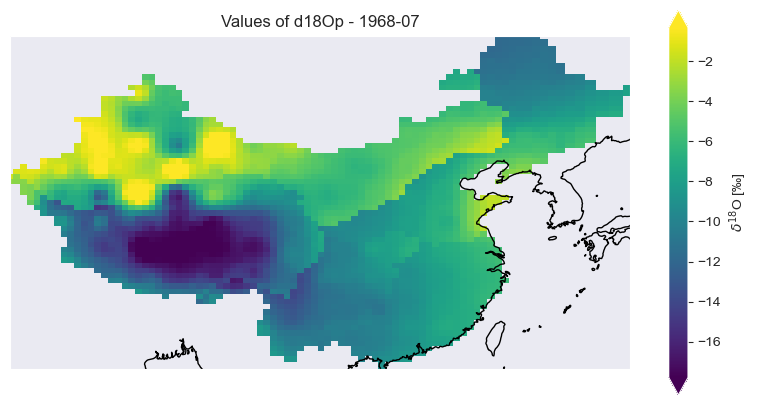

In [3]:
# Plot with cartopy
da_sel = d18Op.sel(time='1968-07-31') #1775
fig,ax = putils.plot_isoscape_latlon_platecarree(da_sel,time='1968-07')
plt.savefig("../output/data_exploration/chen_map1968-07.png",dpi=400)
plt.show()

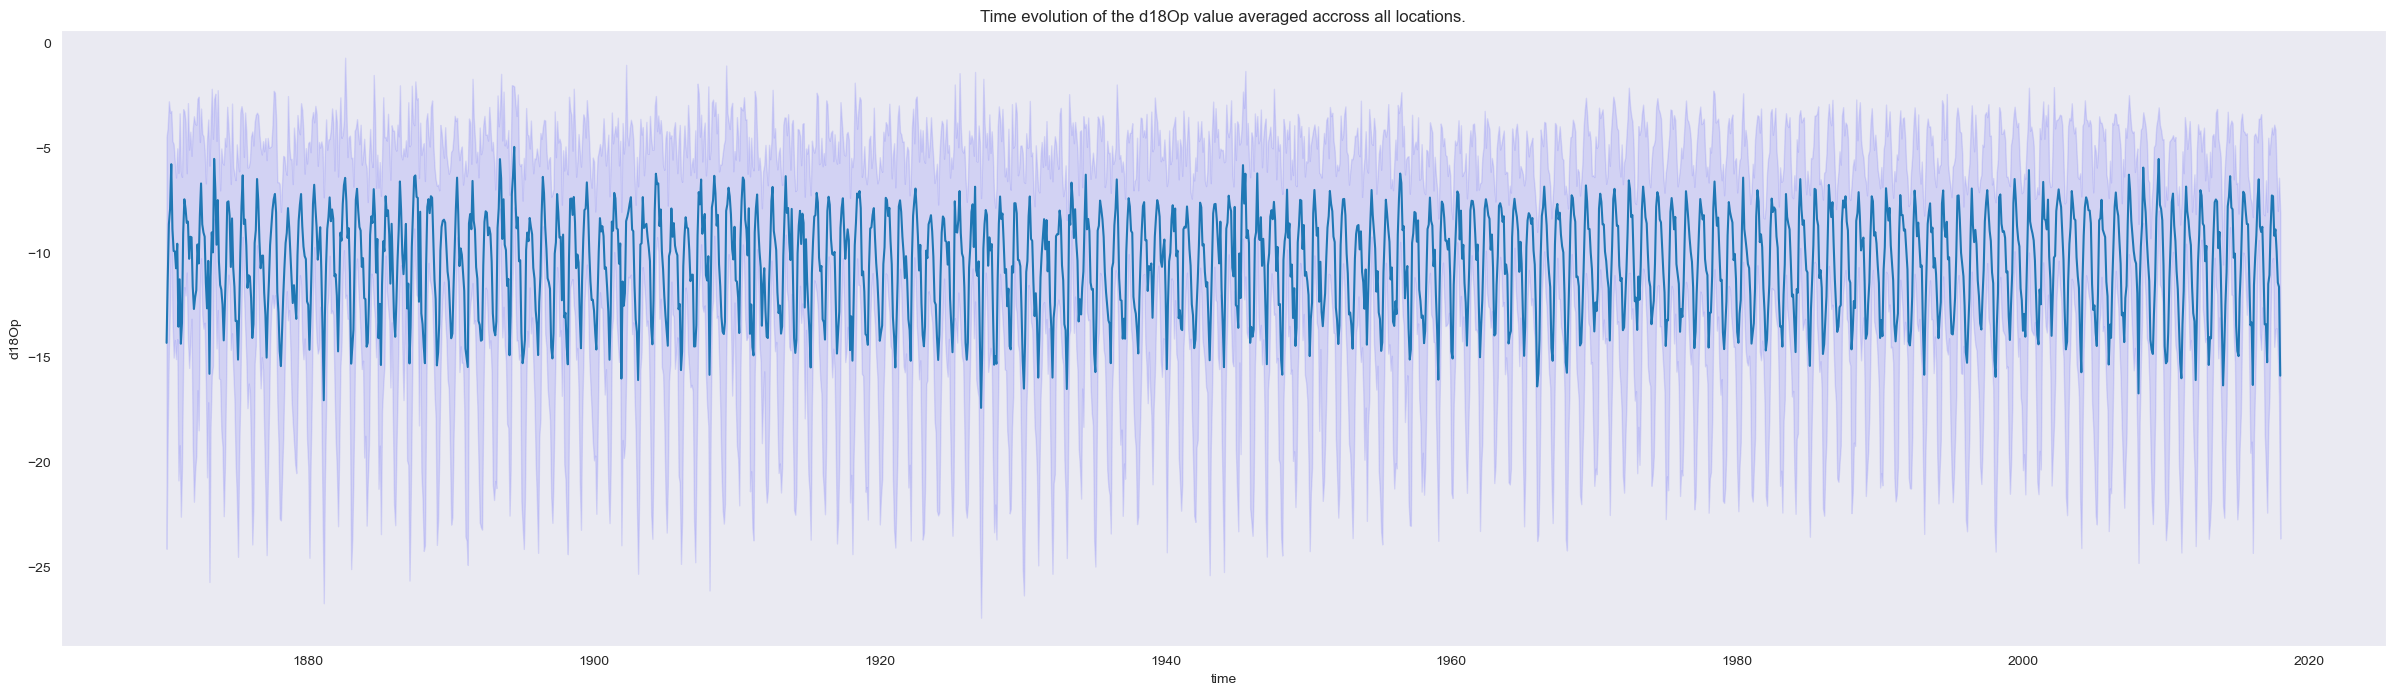

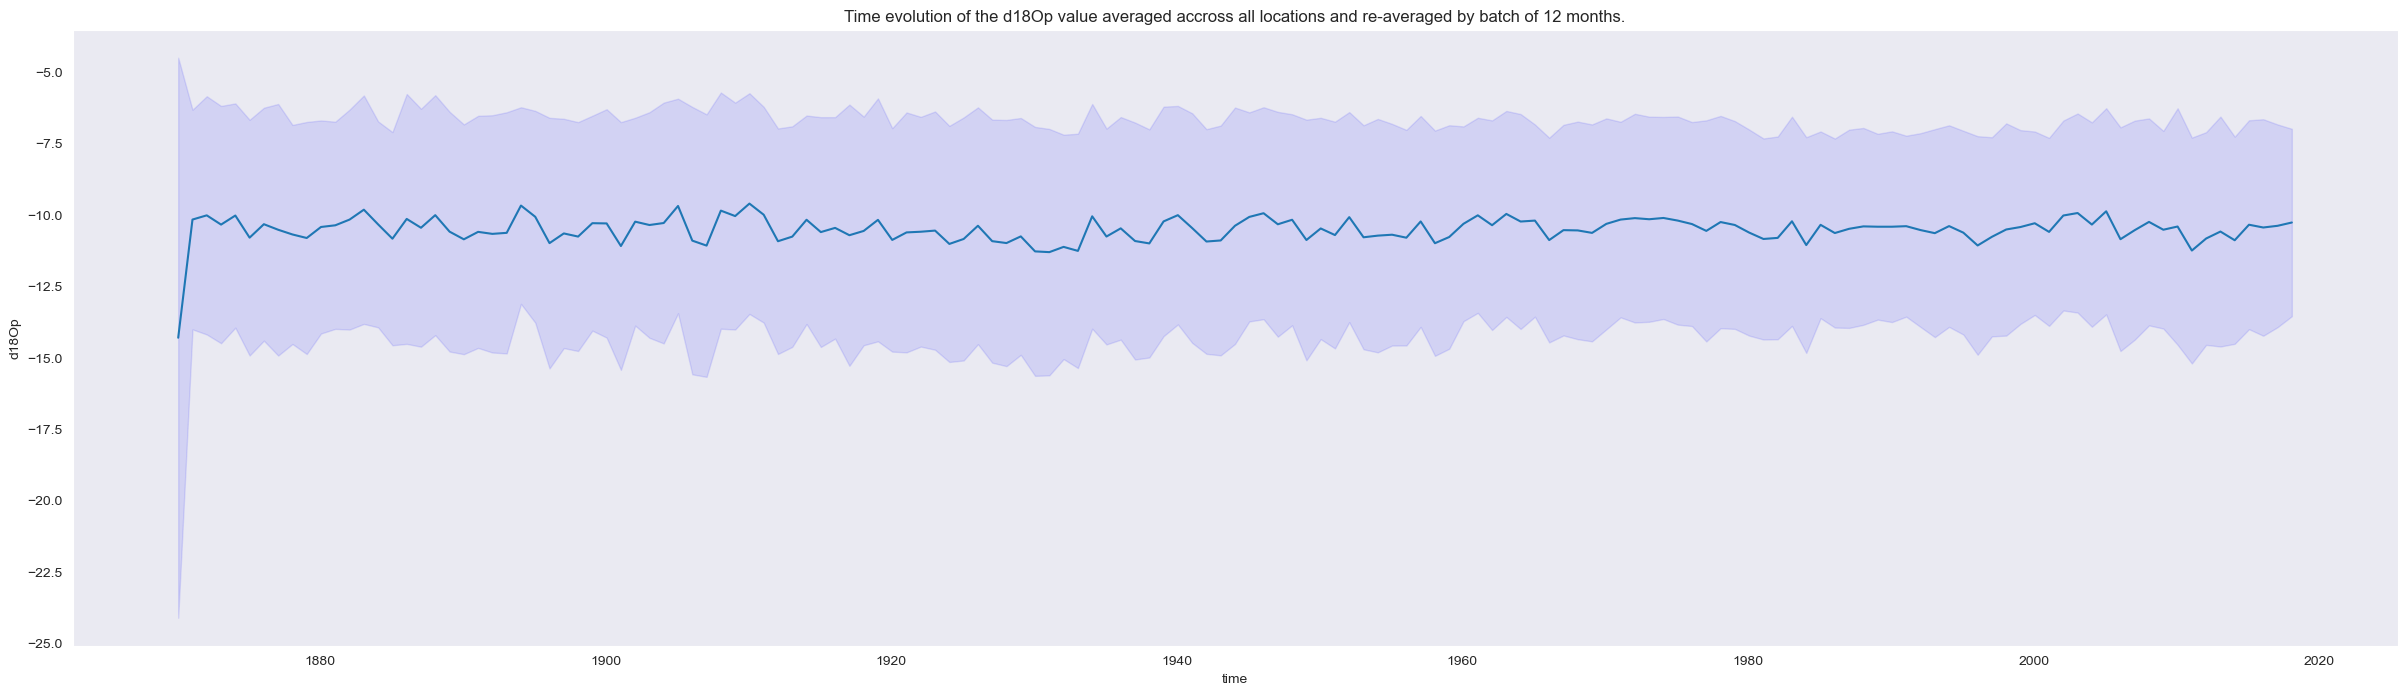

In [4]:
# Mean across all lat/lon with std shown
global_std = d18Op.std(dim=("lat", "lon"))
plt.figure(figsize=(30,8))
global_mean = d18Op.mean(dim=("lat", "lon"))
global_mean.plot.line(x="time")
plt.fill_between(global_mean.time.values, 
                 (global_mean - global_std).values, 
                 (global_mean + global_std).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations.')
plt.show()

# Mean across all lat/lon re-averaged by batch of 12 months
plt.figure(figsize=(30,8))

global_mean_12m = d18Op.resample(time='12ME').mean().mean(dim=("lat", "lon"))
global_std_12m = d18Op.resample(time='12ME').mean().std(dim=("lat", "lon"))
global_mean_12m.plot.line(x="time")
plt.fill_between(global_mean_12m.time.values, 
                 (global_mean_12m - global_std_12m).values, 
                 (global_mean_12m + global_std_12m).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations and re-averaged by batch of 12 months.')
plt.show()

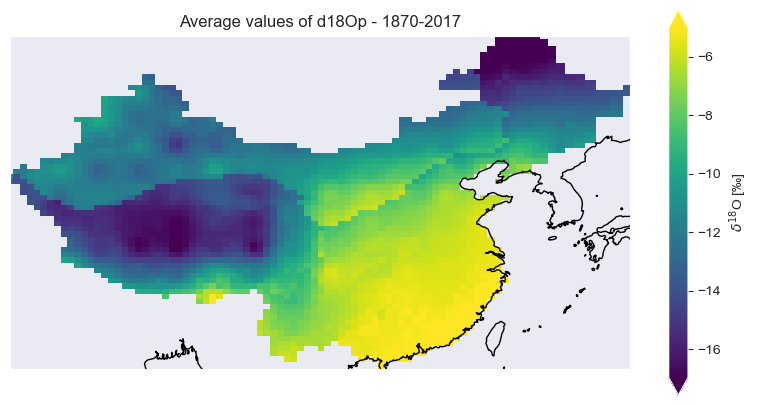

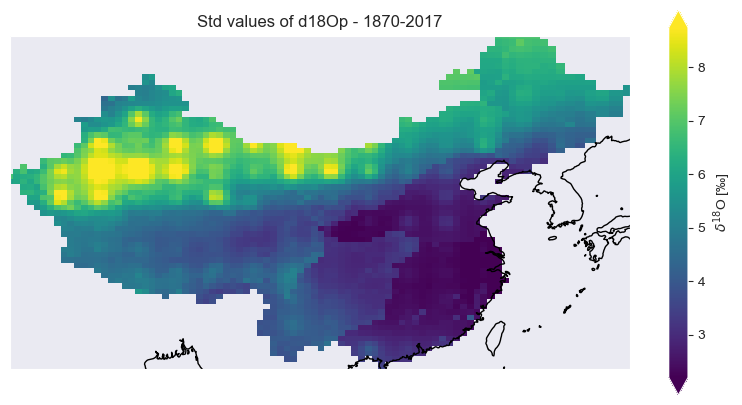

In [5]:
# mean and variance accross time
mean_d18Op = d18Op.transpose('time','lat','lon').mean(dim="time")
std_d18Op = d18Op.transpose('time','lat','lon').std(dim="time")   

fig, ax = putils.plot_isoscape_latlon_platecarree(mean_d18Op, time='1870-2017', title="Average values of d18Op")
plt.show()

fig,ax=putils.plot_isoscape_latlon_platecarree(std_d18Op,time='1870-2017', title='Std values of d18Op')
plt.show()


High varibaility in NW region was explained by authors in the dataset's paper :

*"For NW, the variability of δ18Op simulations is also large. This is because, on the one hand, the sparse coverage of stations coupled with complex topography over northwest China cannot well represent the full range of precipitation isotope conditions. This can lead to biases in the distribution of observations. On the other hand, the arid northwest region is one of the most sensitive regions to climate change due to its fragile ecosystem, which affects sub-cloud evaporation and local moisture re-cycling, leading to the large uncertainty in isotope simulation between different iGCMs23,81."*

### Variogram for a given time point (month)

In [6]:
time = '2006-12-31' 

#### Experimental Variogram (gstat, Euclidean distances) 

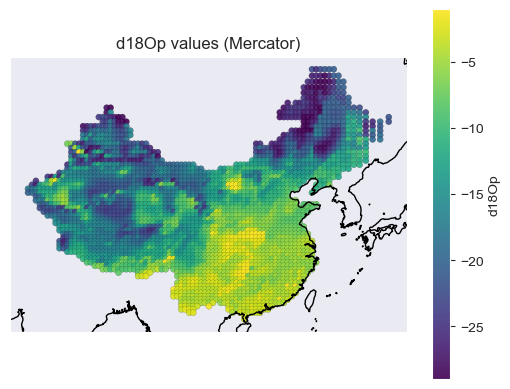

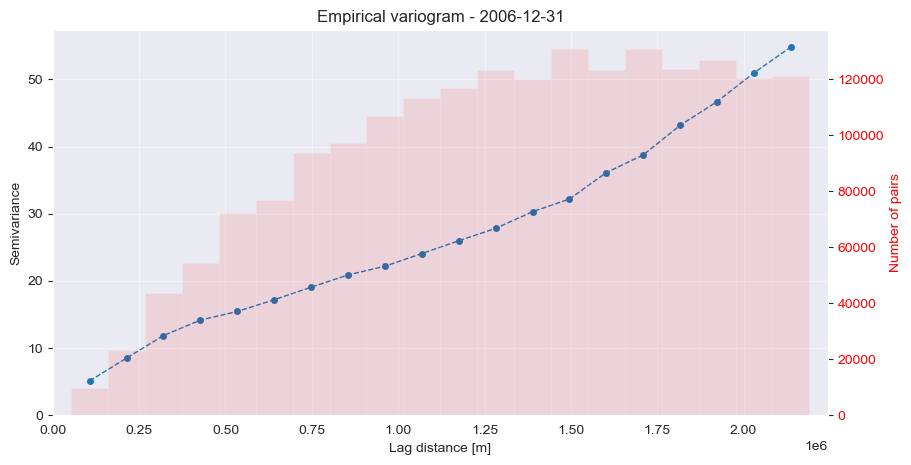

In [7]:
# Prepare data
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")
# Plot projected data
fig, ax = putils.plot_projected_data(coords_proj, vals_s, projection_str='Mercator')
plt.show()

# Compute Variogram
V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   time,V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=False,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model)

#### Experimental Variogram of the **residuals** after trend removal (gstat, Euclidean distances)

Var(original) = 53.63039924335896  Var(residual) = 19.56378951852522


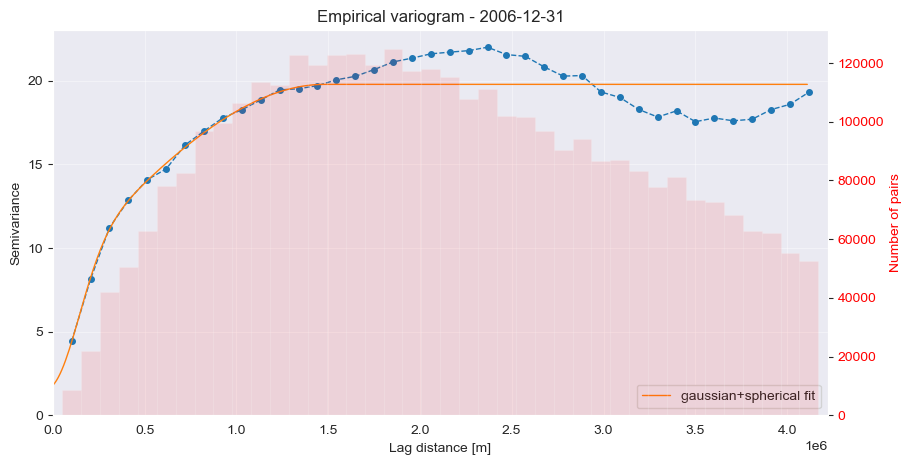

In [ ]:
coords, vals_s = gutils.get_projected_coords_and_vals(d18Op,time=time,epsg="EPSG:3857")

resid = gutils.detrend_data_plane(coords,vals_s)

# quick check: variance reduction after detrend
print("Var(original) =", np.var(vals_s), " Var(residual) =", np.var(resid))

# sensible maxlag: e.g. half the maximum pairwise distance or 1/3
dmax = pdist(coords).max()
maxlag = dmax *0.6

# build variogram on residuals, with metric distances, no normalization
V = skg.Variogram(coords, resid,
                  n_lags=40,
                  maxlag=maxlag,
                  model='gaussian+spherical',
                  use_nugget=True,
                  normalize=False,
                  verbose=True)

fig, ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                    V.experimental,
                                                    time,
                                                    V.bin_count,
                                                    min_pairs=30,
                                                    plot_model=True,
                                                    model_name=V._model_name,
                                                    model_fct = V.fitted_model,
                                                    ) #type:ignore

#### Experimental Variograms using geodesic distances

Max pairwise distance: 4960.0 km


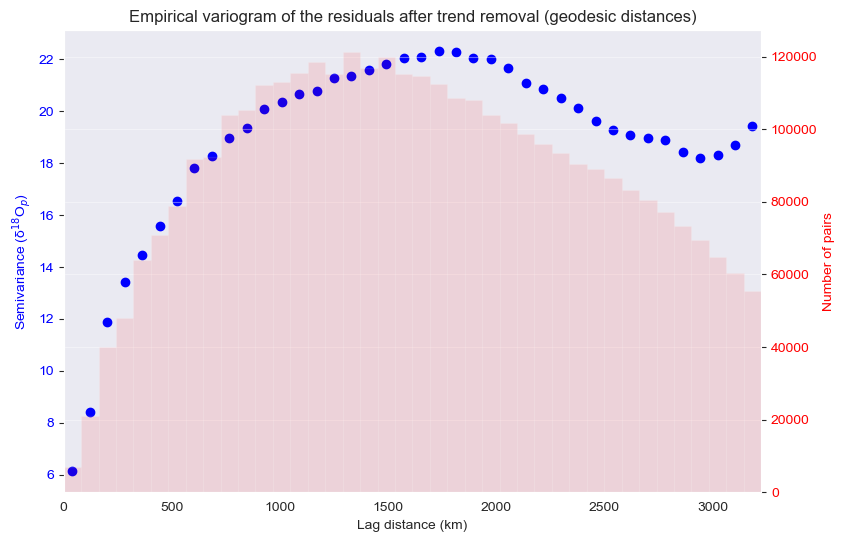

In [11]:
da_slice = d18Op.sel(time=time) 

# Get lon, lat, and values (1D)
lon2d, lat2d = np.meshgrid(da_slice['lon'].values, da_slice['lat'].values)
values = da_slice.values
mask = ~np.isnan(values)
lons = lon2d[mask]
lats = lat2d[mask]
vals = values[mask]
lonlat = np.column_stack((lons, lats))

# remove linear trend 
X = np.column_stack((lons, lats))
residuals = gutils.detrend_data_plane(X,vals)

# Compute distances (meters)
distances = gutils.geodesic_condensed_distances(lonlat)
print(f"Max pairwise distance: {distances.max()/1000:.1f} km")

# Compute semivariances
# pdist (to compute on each pair) with a custom lambda for squared difference (->computes squared diff of each pair)
semivars = pdist(residuals.reshape(-1, 1), lambda u, v: 0.5 * (u - v) ** 2)

# Bin distances into lag classes
n_bins = 40
maxlag = distances.max() * 0.65 
bins = np.linspace(0, maxlag, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Assign each distance to a bin
bin_idx = np.digitize(distances, bins) - 1

# Compute mean semivariance per bin
gamma = np.full(n_bins, np.nan)
counts = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    sel = bin_idx == k
    counts[k] = np.sum(sel)
    if counts[k] > 0:
        gamma[k] = np.mean(semivars[sel])

# Mask unreliable bins (few pairs)
min_pairs = 30  # threshold of minimum pairs per bin
reliable = counts >= min_pairs

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plot semivariance
ax1.plot(bin_centers[reliable]/1000, gamma[reliable], 'o', color='blue', label='Empirical γ(h)')
ax1.set_xlabel('Lag distance (km)')
ax1.set_ylabel('Semivariance (δ$^{18}$O$_p$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Overlay pair counts
ax2 = ax1.twinx()
ax2.bar(bin_centers/1000, counts, width=(bin_centers[1]-bin_centers[0])/1000,
        color='red', alpha=0.1, label='Pair counts')
ax2.set_ylabel('Number of pairs', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.xlim(0, maxlag/1000)
plt.title('Empirical variogram of the residuals after trend removal (geodesic distances)')
plt.grid(True, alpha=0.4)
plt.show()

#### *drafts - variograms computations*

In [ ]:
coord_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

centers, gamma, counts = gutils.variogram_gstools(coords_proj, vals_s, n_bins=40, maxlag=4000000)

# plot
fig, ax = putils.plot_variogram_from_bins_and_gamma(centers,gamma,time,counts,min_pairs=30)
plt.show()

In [ ]:
# prepare A (meshgrid) and B (to_dataframe) again
da_slice = d18Op.sel(time='1969-12-31')
lons = da_slice['lon'].values
lats = da_slice['lat'].values
lon_grid, lat_grid = np.meshgrid(lons, lats,indexing='ij')   # <- indexing='ij' to preserve order
coords = np.column_stack([lon_grid.ravel(order='C'), lat_grid.ravel(order='C')])
values = da_slice.values.ravel(order='C')
mask = ~np.isnan(values)
coords_A = coords[mask]
vals_A = values[mask]

df = d18Op.to_dataframe(name='d18Op').reset_index()
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset=['d18Op']).copy()
coords_B = df[['lon','lat']].values
vals_B = df['d18Op'].values

print('counts A,B:', coords_A.shape[0], coords_B.shape[0])
print('da_slice.shape, coords grid shape:', da_slice.shape, lon_grid.shape)

# compare lon/lat pairs before projection
setA = set(map(tuple, np.round(coords_A, 6)))
setB = set(map(tuple, np.round(coords_B, 6)))
print('n only in A:', len(setA - setB))
print('n only in B:', len(setB - setA))
# show some examples
print('examples only in A (first 5):', list(setA - setB)[:5])
print('examples only in B (first 5):', list(setB - setA)[:5])

# check lon ranges / ordering
print('lons range (grid):', lons.min(), lons.max())
print('lons range (df):', df['lon'].min(), df['lon'].max())
print('first/last lats:', lats[:3], lats[-3:])
print('unique lat ordering in df head/tail:', df['lat'].unique()[:3], df['lat'].unique()[-3:])

In [ ]:
import cartopy.crs as ccrs
from pyproj import Transformer

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point')   # or ('lon','lat') to match your desired order
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])
print(coords_proj)

# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
# sc = ax.scatter(lons_s, lats_s, c=vals_s, s=20, cmap="viridis", transform=ccrs.PlateCarree(), alpha=0.9, edgecolor="k", linewidth=0.1)
# ax.coastlines(resolution="50m")
# ax.set_title("d18Op values (lon/lat)")
# plt.colorbar(sc, ax=ax, label="d18Op")
# plt.show()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(xs, ys, c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()


#### Directional variograms (gstat)

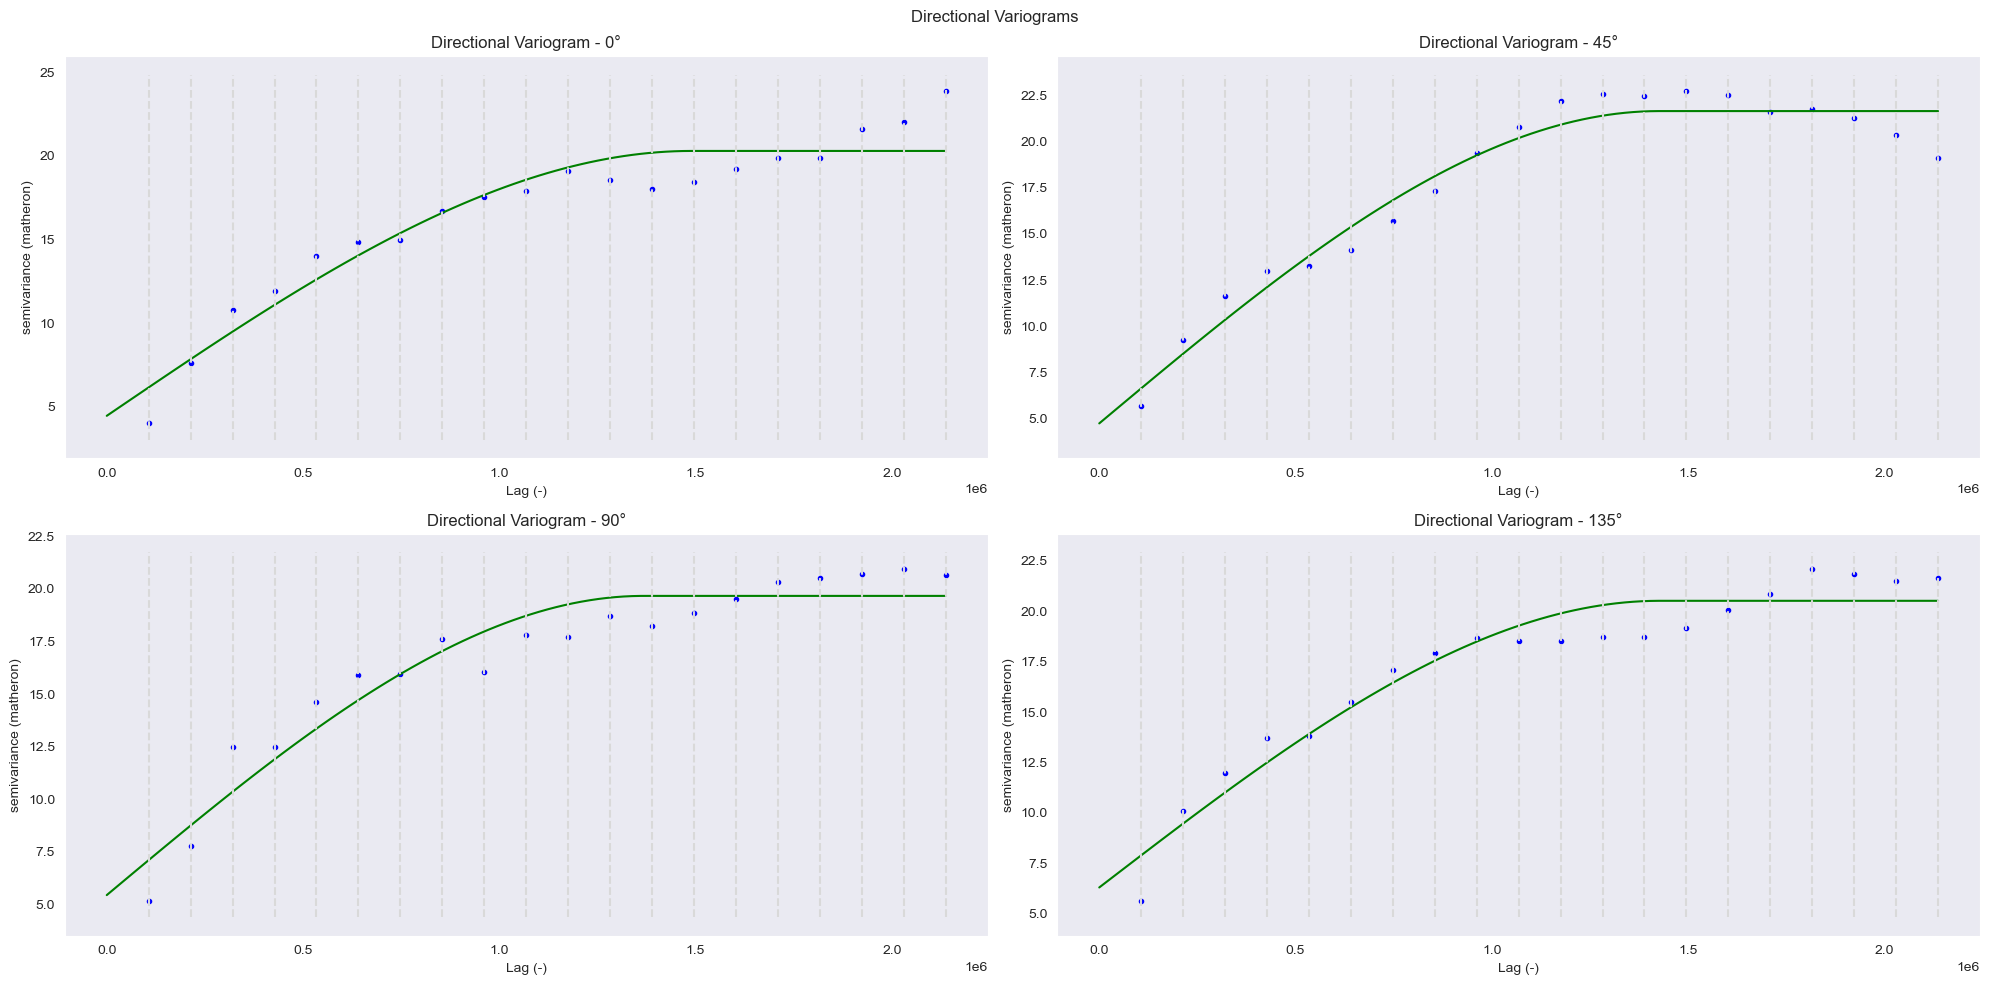

Range in direction 0°: 15.842246338331643
Range in direction 45°: 16.891785974743023
Range in direction 90°: 14.23212392465381
Range in direction 135°: 14.196075768557355
Anisotropy Ratio: 1.1898912241759338
Anisotropy Direction: 45°


In [12]:
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

resid = gutils.detrend_data_plane(coords_proj,vals_s)

# # show the map of data and residuals again 
# fig, ax = putils.plot_projected_data(coords_proj,vals_s,'Mercator')
# plt.show()
# fig,ax = putils.plot_projected_data(coord_proj,resid,'Mercator')
# plt.show()

# Compute directional variogram
directions = [0,45,90,135]
ranges = []
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()
for i, direction in enumerate(directions):
    V_dir = skg.DirectionalVariogram(coords_proj,resid,n_lags=20,maxlag='median',
                                     model='spherical',use_nugget=True,normalize=False,
                                     azimuth=direction,tolerance = 22.5 )
    ranges.append(V_dir.parameters[1])
    V_dir.plot(axes=axes[i], show=False, grid=True)
    axes[i].set_title(f'Directional Variogram - {direction}°')
plt.suptitle('Directional Variograms')
plt.tight_layout()
plt.show()

for dir, r in zip(directions, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {directions[max_range_index]}°')


### Global variograms

In [14]:
# convert the xarray into dataframe
df = d18Op.to_dataframe(name='d18Op').reset_index().dropna()
# df = df[( df['time'].dt.month.isin([10,11,12,1,2,3,4]))] # Moonsoon = May to September

df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")

bins, bin_count, gammas = None, None, []
for t, g in tqdm(df.groupby('time')):
    if g['d18Op'].notna().sum() < 30:
        continue
    try:
        b, g_exp, bin_count,_ = gutils.variogram_with_gstat(g,quantity='d18Op',trend='plane',maxlag='median',return_Variogram_object=False) # type: ignore
        # at each time step the locations stay the same, so bins and bin counts are constant
        if bins is None:
            bins = b
            bin_count = bin_count
        # append the semivariances to the list
        gammas.append(g_exp)
    except Exception as e:
        print(f"Skipped {t}: {e}")

  2%|▏         | 35/1776 [00:34<28:41,  1.01it/s]


KeyboardInterrupt: 

**Motivation for computing each variogram separetly**:

There is the same number of pairs at each timestep. Hence, if the variogram is computed for each timestep separately and then the mean is taken, it is equivalent to computing the variogram directly with all pairs from all timesteps (which would require an immense amount of memory). 

This is due to the fact that the value of the variogram at one bin is the mean semivariance at lag h, and a sum of means is the mean of the sum only if each sum has the same number of elements.

In [ ]:
mean_gamma = np.nanmedian(np.vstack(gammas), axis=0)
mean_df = pd.DataFrame({'lag': bins, 'gamma': mean_gamma,'bin_count':bin_count})
fig, ax = putils.plot_variogram_from_bins_and_gamma(mean_df['lag'],mean_df['gamma'],time='1870-2017',counts = bin_count) #type:ignore
plt.show()

In [ ]:
mean_df.to_csv('../output/variograms/global_variogram_df_chen.csv')

## iTrace dataset

This dataset is the output of the iTrace simulation (Community Land Model from iCESM).

We download the files at this [link](https://gdex.ucar.edu/datasets/d651022/dataaccess/#), with the naming conventions explained [here](https://yefee.github.io/iTRACE/).

The quantity $\delta^{18}\text{O}$ is not directly available, we must compute it from the total water trace (H2OTR, in m/s) data and the heavy oxygen water precipitation data (H218O, in m/s).


>The name of the files is consituted of (from left to right)
   >
   > 1. `b.e13.Bi1850C5`: the machine used for the iTrace simulation
   >
   > 1. `f19_g16`: the spatial resolution of the simulation (about 1.9° lat x 2.5° lon).
   >
   > 1. `xxka`: the temporal slice of the simulation (see the documentation for precise info)
   >
   > 1. `ice_ghg_orb_wtr.0x` or any subset of it : the forcings applied during the simulation.
   >
   > 1. `clm2`: the Community Land Model version 2 (cam2 for atmoshperic model...)
   >
   > 1. the name after all is the variable name.

##### Detailed procedure of the delta 18O computation from itrace files (now wrapped in a more sophisticated function, including snowfall...)

In [2]:
fn_itrace_H218O = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H218O.800001-899912.nc'
fn_itrace_H2OTR = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H2OTR.800001-899912.nc'

file_H218O = utils.load_xarray_datarray(fn_itrace_H218O)
file_H2OTR = utils.load_xarray_datarray(fn_itrace_H2OTR)

# print(file_H218O.info())
# print(file_H2OTR.info())

h218o = file_H218O.RAIN_H218O
h2o = file_H2OTR.RAIN_H2OTR

The fluxes (in mm/s) are actually already corrected for the molar mass and VSMOW standard by the iCESM model (see this [forum](https://bb.cgd.ucar.edu/cesm/threads/how-can-i-use-the-output-variables-of-icesm-to-generate-%CE%B418o-in-atmospheric-precipitation.10990/)). 

Hence, $R_{^{18}O} = \frac{n_{^{18}O}}{n_{^{16}O}} = \frac{f_{^{16}O}}{f_{^{18}O}} $

In [3]:
# ---- No need of this correction --- 
# Divide the mm/s by the molar mass to get molar-mass corrected fluxes
# M16 = 18.01056468403e-3  # kg/mol
# M18 = 20.01481106446e-3
# R_vsmow = 0.0020052
# mol_ratio = (h218o / h2o) * (M16 / M18)
# delta18 = ( mol_ratio / R_vsmow - 1.0) * 1000.0

# Compute delta 18 O (per thousand)
delta18 = ( h218o/h2o - 1.0) * 1000.0
delta18 = delta18.where((h2o > 1e-12)&(delta18 < 100))  # avoid div by near-0 precip values and positive outliers (delta18 should be mostly negative and small -20/+20)


Let us fix the time scale and unit : we do like to work in ka BP.

The time dimension is in units of days after a base-day. 

If everything is alright, we shoudl find approximately one point every month, spanning 700 years in total (in noleap mode) from 11.7 kyBP to 11kyBP.

In [ ]:
time_series = pd.Series(delta18.time.values)
minres = time_series.sort_values().diff().min()
maxres = time_series.sort_values().diff().max()
print('minimum spacing is ',minres)
print('max spacing is :', maxres)

da = delta18

tmin, tmax = float(da.time.min()), float(da.time.max())
bins = np.arange(tmin, tmax + int(maxres), int(maxres)) #type:ignore

da_binned = da.groupby_bins('time', bins=bins).mean()
da_binned = da_binned.rename({'time_bins': 'time'})
delta18_binned = da_binned.assign_coords(time=bins[:-1])

In [ ]:
bins[-7000]

In [ ]:
plt.figure(figsize=(7,3))
plt.hist(time_series.sort_values().diff(),bins=40)
plt.xlabel('days between 2 consecutive points')
plt.ylabel('count')
plt.grid(True)
plt.show()

In [ ]:
time = delta18.time.values

days_since_start = time - time[0]
years_since_start = days_since_start / 365.0  # model years
# Convert to ka BP (this chunk = 11.7 -> 11 kaBP)
yrBP = 11700 - years_since_start 

print('Years BP : ',yrBP[:])
# Assign the new coordinate
delta18_yrBP = delta18.assign_coords(time=("time", yrBP)).copy()

In [ ]:
time = bins[-7000] 
to_plot = delta18_binned.sel(time=time)
# map of the mean d18O 
fig,ax = putils.plot_isoscape_latlon_platecarree(to_plot,time=f'{time} yr BP', countries_borders=True)
# plt.savefig('../output/data_exploration/itrace_map_example.png',dpi=500)
plt.show()  

Now, let us mask the region of interest using a shapefile.

In [ ]:
import geopandas as gpd
fn_countries = "../data/shapefiles/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(fn_countries)

In [ ]:
countries = world.loc[world['CONTINENT'].isin(['Europe','Asia']),'NAME'].to_list()
region_da_yrBP = utils.mask_country_shape(delta18_yrBP,country_names=countries)
region_da_binned = utils.mask_country_shape(delta18_binned,country_names=countries)

##### Load itrace (clean fct)

In [20]:
countries = None #['China']
delta18_binned, prect_da = gutils.get_itracedata_for_external_drift(res=31,include_snow=True,prect_da=True,delta18_da=True,countries=countries)
time = delta18_binned.time.values[-1398]

Prepare the data and external variables to use for fitting a trend model (used for variography)

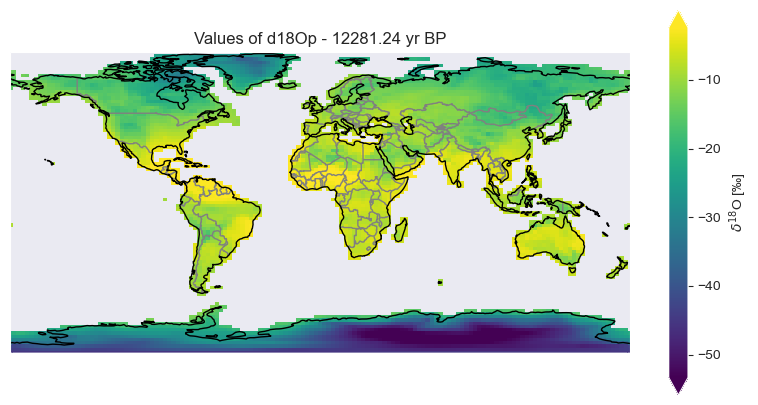

-> Adding external variables ['elev', 'dcoast'].
   > elevation data will be taken from file ../data/elevation/ETOPO_2022_v1_60s_N90W180_surface.nc
   > coastlines will be taken from file ../data/shapefiles/ne_10m_coastline/ne_10m_coastline.shp


In [21]:
da = delta18_binned #region_da_binned

fig,ax = putils.plot_isoscape_latlon_platecarree(da.sel(time=time),time=f'{utils.get_yrBP_from_itrace_time(time):.2f} yr BP',countries_borders=True) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

df=da.sel(time=time).to_dataframe(name='d18Op').reset_index().dropna(subset='d18Op') # type:ignore

df_prect = prect_da.sel(time=time).to_dataframe(name='prect').reset_index().dropna(subset='prect') #type:ignore

df = pd.merge(df,df_prect,how='left',on=['lon','lat','time'])

df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")

df = gutils.add_external_variables_to_lonlat_df(df,time=time,variables=['elev','dcoast'])


> We start by computing a first variogram on a single isoscape (one time-step). 

> Since the dataset contains lots of missing values for some isoscapes, we make sure to choose a time step at which there is no missing value in China. \
> This way, we can extract the bins of the variogram and consider them as reference bins. \
> We will use these reference bins to make variograms for all time steps (all isoscapes), in order to be able to aggregate the results per bin.
> 


##### Variogram for one time step

The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m', 'prect']
-> detrending with multilinear model, full R^2=0.896, contributions: {'lat': np.float64(0.010507692642510516), 'lat2': np.float64(0.2830952185823364), 'elevation': np.float64(0.053082745221629195), 'dist_coast_m': np.float64(0.005661022014590646), 'prect': np.float64(0.0009306119767255083)}


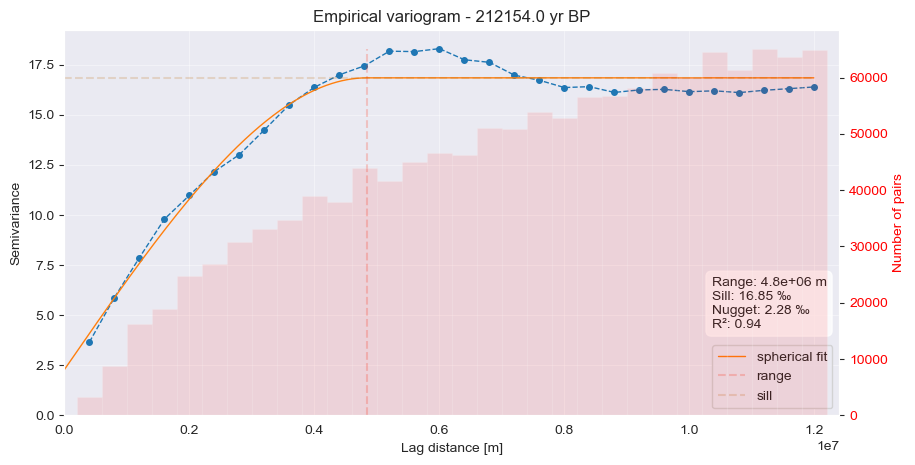

In [22]:
V = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multilinear_lat_prect_elev_dcoast',
                                maxlag=1.2e7,
                                nlags=30,
                                return_Variogram_object=True,
                                model='spherical'
                                )
ref_bins = V.bins
parameters_dict= gutils.get_vario_parameters_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'{time} yr BP',
                                                   V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params= parameters_dict
                                                   ) #type:ignore
plt.show()

The predictors are  ['lat', 'lat2', 'elevation', 'dist_coast_m', 'prect']
Total R^2 = 0.8972619415684194
Variance contributions: {'lat': np.float64(0.011066203191647285), 'lat2': np.float64(0.2859178301745669), 'elevation': np.float64(0.05458969668509703), 'dist_coast_m': np.float64(0.0061238820907991405), 'prect': np.float64(0.0007865659019379854)}
Regression coefficients: [-1.63320269e+00  2.97924822e-02 -3.68756342e-03 -3.95541327e-03
 -2.31926646e-06 -6.23753787e-03]


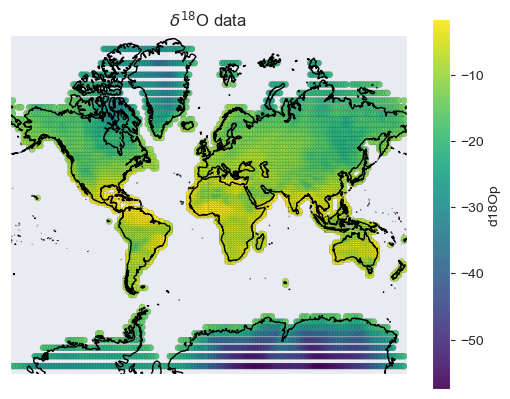

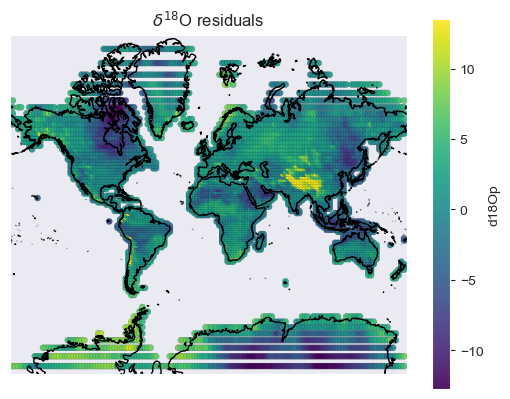

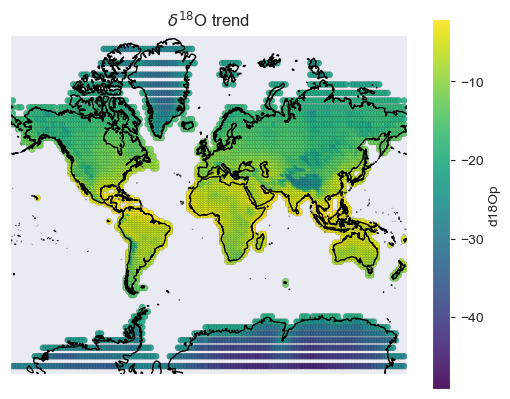

In [23]:
detrended_df, r2, contributions, beta = gutils.detrend_multilinear(df,dist_col='dist_coast_m',include_dcoast=True,include_elev=True,include_prect=True)
print("Total R^2 =", r2)
print("Variance contributions:", contributions)
print("Regression coefficients:", beta)

fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

##### Variogram for all time steps

**Global variogram computation:** 
1. Convert the xarray DataArray into a dataframe 
1. Project coordinates
1. Loop on all time steps, compute variogram, append results to lists
1. Aggregate the results into one variogram (details below)
1. Plot

> Steps 2. and 3. are gathered in function ```gutils.iterative_variogram_computations```\
> Step 4. is achieved by function ```gutils.aggregate_variograms```

In [8]:
# convert the xarray into dataframe (and choose time range if needed (intervals of 31 days))

# mask = (china_da_binned.time >= 76840) & (china_da_binned.time <= 80000)
# df = china_da_binned.sel(time=mask).to_dataframe(name='d18Op').reset_index().dropna()
# df = china_da_binned.to_dataframe(name='d18Op').reset_index().dropna()
df = delta18_binned.to_dataframe(name='d18Op').reset_index().dropna() # type:ignore

KeyboardInterrupt: 

In [ ]:
print('All directions')
bin_count,gammas, _ = gutils.iterative_variogram_computations(df,ref_bins)
df_all = gutils.aggregate_variograms(bin_counts=bin_count,gammas=gammas,bins=ref_bins)
df_all.to_csv('../output/variograms/asia_alltimes_variogram_df_itrace.csv')
print('finished')
# print('computation dir=0')
# bin_count0,gammas0, _ = gutils.iterative_variogram_computations(df,ref_bins,direction=0)
# df0 = gutils.aggregate_variograms(bin_counts=bin_count0,gammas=gammas0,bins=ref_bins)
# df0.to_csv('../output/variograms/global_alltimes_variogram_d0_df_itrace.csv')

# print('computation dir=45')
# bin_count45,gammas45, _ = gutils.iterative_variogram_computations(df,ref_bins,direction=45)
# df45 = gutils.aggregate_variograms(bin_counts=bin_count45,gammas=gammas45,bins=ref_bins)
# df45.to_csv('../output/variograms/global_alltimes_variogram_d45_df_itrace.csv')

# print('computation dir=90')
# bin_count90,gammas90, _ = gutils.iterative_variogram_computations(df,ref_bins,direction=90)
# df90 = gutils.aggregate_variograms(bin_counts=bin_count90,gammas=gammas90,bins=ref_bins)
# df90.to_csv('../output/variograms/global_alltimes_variogram_d90_df_itrace.csv')

# print('computation dir=135')
# bin_count135,gammas135, _ = gutils.iterative_variogram_computations(df,ref_bins,direction=135)
# df135 = gutils.aggregate_variograms(bin_counts=bin_count135,gammas=gammas135,bins=ref_bins)
# df135.to_csv('../output/variograms/global_alltimes_variogram_d135_df_itrace.csv')

>**Aggregation of the variogram:**\
> Unlike Chen dataset, we can find lots of missing values in iTrace for some time slices.\
> Hence, there is not the same number of pairs at each time slice, so the mean computation must be weighted according to the pair counts!

In [ ]:
df_all = pd.read_csv('../output/variograms/china_alltimes_variogram_df_itrace.csv')
# df0 = pd.read_csv('../output/variograms/global_variogram_d0_df_itrace.csv')
# df45 = pd.read_csv('../output/variograms/global_variogram_d45_df_itrace.csv')
# df90 = pd.read_csv('../output/variograms/global_variogram_d90_df_itrace.csv')
# df135 = pd.read_csv('../output/variograms/global_variogram_d135_df_itrace.csv')


In [ ]:
# plot global variogram - nallo directions
fig, ax = putils.plot_variogram_from_bins_and_gamma(df_all['lag'],df_all['gamma'],time='11.7 to 11 ka BP (weighted average)',counts=df_all['count']) #type:ignore
plt.show()
# plot directional variograms
# list = [df0,df45,df90,df135]
# list_dir=[0,45,90,135]
# fig,axes=plt.subplots(2,2,figsize=(17,9))
# for i in range(2):
#     for j in range(2):
#         df_to_plot = list[i+2*j]
#         axes[i,j] = putils.plot_variogram_from_bins_and_gamma(df_to_plot['lag'],df_to_plot['gamma'],time=f'11.7 to 11 ka BP - {list_dir[i+2*j]}',counts=df_to_plot['count'],ax_= axes[i,j])
#         axes[i,j].set_title(f'Dir={list_dir[i+2*j]}')
# plt.show()

## Modelling on aggregated variograms

In [13]:
chen_variogram_df = pd.read_csv('../output/variograms/alltimes_variogram_df_chen.csv').rename(columns={'bin_count':'count'})
itrace_variogram_df_all = pd.read_csv('../output/variograms/asia_alltimes_variogram_df_itrace.csv')
# itrace_variogram_df0 = pd.read_csv('../output/variograms/global_variogram_d0_df_itrace.csv')
# itrace_variogram_df45 = pd.read_csv('../output/variograms/global_variogram_d45_df_itrace.csv')
# itrace_variogram_df90 = pd.read_csv('../output/variograms/global_variogram_d90_df_itrace.csv')
# itrace_variogram_df135 = pd.read_csv('../output/variograms/global_variogram_d135_df_itrace.csv')

dict_dfs= {
            'c_all':{'df': chen_variogram_df},
           'i_all': {'df': itrace_variogram_df_all},
        #    'i_0': {'df': itrace_variogram_df0},
        #    'i_45': {'df': itrace_variogram_df45},
        #    'i_90': {'df': itrace_variogram_df90},
        #    'i_135': {'df': itrace_variogram_df135}
        }

In [14]:
model_name = 'composite'

for key in dict_dfs.keys():
    print(key)
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bins=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

# params_itrace,fct_fitted_itrace,pcov_itrace = gutils.fit_variogram_model(bins=itrace_variogram_df_all['lag'],
#                                                                        gammas=itrace_variogram_df_all['gamma'],
#                                                                        model=model_name,
#                                                                        pair_counts=itrace_variogram_df_all['bin_count']
#                                                                        )

c_all
i_all


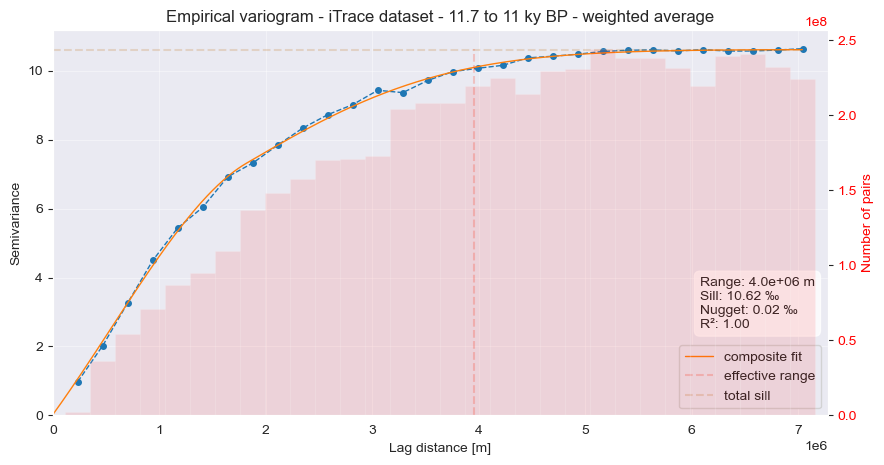

In [16]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=itrace_variogram_df_all['count'],
                                          min_pairs=20,
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name='../output/variograms/fig_asia_alltimes_variogram_and_model_itrace.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

# fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['c_all']['df']['lag'],
#                                           gamma=dict_dfs['c_all']['df']['gamma'],
#                                           time='Chen dataset - 1870 to 2017 - weighted average',
#                                           counts=chen_variogram_df['count'],
#                                           min_pairs=20,
#                                           plot_model=True,
#                                           model_name=model_name,
#                                           model_fct=dict_dfs['c_all']['fct_fitted'],
#                                           model_params=dict_dfs['c_all']['params'],
#                                           figsize=(10,5),
#                                           save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
#                                           ) #type:ignore
# plt.show()
# plt.close('all')

In [ ]:
# with open('../output/variograms/global_variogram_model_dict_chen.json', 'w') as fp:
#     json.dump(dict_dfs['c_all']['params'], fp)
# with open('../output/variograms/global_variogram_model_dict_itrace.json', 'w') as fp:
#     json.dump(dict_dfs['i_all']['params'], fp)

In [ ]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            min_pairs=20,
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        if model_name !='composite':
            ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')